In [1]:
%load_ext autoreload
%autoreload 2

In [14]:
from dotenv import load_dotenv
load_dotenv()

True

In [15]:
%pip install -q -U -r requirements.txt
%pip install uv --quiet

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [16]:
dbutils.library.restartPython()

In [17]:
import asyncio
import functools
import os
import uuid
from datetime import datetime
from typing import Any, Dict, Generator, List, Literal, Optional
from zoneinfo import ZoneInfo

import mlflow
from databricks.sdk import WorkspaceClient
from databricks_langchain import ChatDatabricks
from databricks_langchain.genie import GenieAgent
from langchain_core.runnables import RunnableLambda
from langgraph.graph import END, StateGraph, add_messages
from langgraph.graph.state import CompiledStateGraph
from langgraph.prebuilt import create_react_agent
from mlflow.entities import SpanType
from mlflow.pyfunc import ChatAgent
from mlflow.types.agent import (
    ChatAgentChunk,
    ChatAgentMessage,
    ChatAgentResponse,
    ChatContext,
)
from pydantic import BaseModel
from typing_extensions import Annotated, TypedDict
from langgraph.checkpoint.memory import MemorySaver

mlflow.set_tracking_uri("databricks")

######################################
## Load variables from the config file
######################################

# TODO make sure you update the config file
configs = mlflow.models.ModelConfig(development_config="./configs.yaml")
agent_configs = configs.get("agent_configs")

LLM_ENDPOINT_NAME = agent_configs.get("llm").get("endpoint_name")
LLM_TEMPERATURE = agent_configs.get("llm").get("temperature")
GENIE_SPACE_ID = agent_configs.get("genie_agent").get("space_id")
GENIE_DESCRIPTION = agent_configs.get("genie_agent").get("description")
PARALLEL_EXECUTOR_DESCRIPTION = agent_configs.get("parallel_executor_agent").get(
    "description"
)

MAX_ITERATIONS = agent_configs.get("supervisor_agent").get("max_iterations")

SYSTEM_PROMPT = agent_configs.get("supervisor_agent").get("system_prompt")
RESEARCH_PROMPT = agent_configs.get("supervisor_agent").get("research_prompt")
FINAL_ANSWER_PROMPT = agent_configs.get("supervisor_agent").get("final_answer_prompt")

###################################################
## Create a GenieAgent with access to a Genie Space
###################################################

genie_agent = GenieAgent(
    genie_space_id=GENIE_SPACE_ID,
    genie_agent_name="Genie",
    description=GENIE_DESCRIPTION,
    client=WorkspaceClient(
        host=os.getenv("DB_MODEL_SERVING_HOST_URL"),
        token=os.getenv("DATABRICKS_GENIE_PAT"),
    ),
)

############################################
# Define your LLM endpoint and system prompt
############################################
llm = ChatDatabricks(
    endpoint=LLM_ENDPOINT_NAME,
    temperature=LLM_TEMPERATURE,
)


################################################
# Create calendar functions for temporal context
################################################


def get_temporal_context() -> Dict[str, str]:
    """Return current date, fiscal year, and fiscal quarter.

    Fiscal year runs Sep 1 -> Aug 31, labeled by end year.
    Quarters: Q1=Sep-Nov, Q2=Dec-Feb, Q3=Mar-May, Q4=Jun-Aug
    """
    now = datetime.now(ZoneInfo("America/New_York"))
    today_iso = now.date().isoformat()

    # Fiscal year calculation (Sep-Aug, labeled by end year)
    fy_end_year = now.year + 1 if now.month >= 9 else now.year
    fy = f"FY{fy_end_year}"

    # Fiscal quarter calculation
    if now.month in (9, 10, 11):
        fq = "Q1"
    elif now.month in (12, 1, 2):
        fq = "Q2"
    elif now.month in (3, 4, 5):
        fq = "Q3"
    else:  # Jun, Jul, Aug
        fq = "Q4"

    return {
        "today_iso": today_iso,
        "fy": fy,
        "fq": fq,
    }

In [18]:
#################################################################
# Define the supervisor agent with research planning capabilities
#################################################################

worker_descriptions = {
    "Genie": GENIE_DESCRIPTION,
    "ParallelExecutor": PARALLEL_EXECUTOR_DESCRIPTION,
}

formatted_descriptions = "\n".join(
    f"- {name}: {desc}" for name, desc in worker_descriptions.items()
)

options = ["FINISH"] + list(worker_descriptions.keys())
FINISH = {"next_node": "FINISH"}


class NextNode(BaseModel):
    next_node: Literal[tuple(options)]


class ResearchPlan(BaseModel):
    queries: List[str]
    rationale: str


class ResearchPlanOutput(BaseModel):
    should_plan_research: bool
    research_plan: Optional[ResearchPlan] = None
    next_node: Literal[tuple(options)]


@mlflow.trace(span_type=SpanType.AGENT, name="supervisor_routing")
def supervisor_agent(state):
    """Supervisor agent node that prepends temporal org context to the system prompt
    and then decides whether to plan research or route normally.

    The injected context includes:
      - Current date (America/New_York)
      - Current fiscal year (FY named by end year, Sep→Aug)
      - Current fiscal quarter (Q1..Q4, with Q1 starting in September)
    """
    try:
        count = state.get("iteration_count", 0) + 1
        if count > MAX_ITERATIONS:
            return FINISH

        # Build dynamic system prompt
        temporal_ctx = get_temporal_context()

        # Keep the context compact and machine-friendly at the very top of the system prompt.
        temporal_prefix = (
            "Below is information on the current date and fiscal year/quarter information. You may or may not use this in your analysis.\n"
            f"- The current date is: {temporal_ctx['today_iso']}\n"
            f"- The current fiscal year is: {temporal_ctx['fy']}\n"
            f"- The current fiscal quarter is: {temporal_ctx['fq']}\n\n"
        )

        SYSTEM_PROMPT_WITH_CONTEXT = temporal_prefix + SYSTEM_PROMPT
        SYSTEM_PROMPT_WITH_CONTEXT_AND_RESEARCH = (
            temporal_prefix + SYSTEM_PROMPT + "\n\n" + RESEARCH_PROMPT
        )

        # Preprocessors that include the dynamic prefix
        preprocessor = RunnableLambda(
            lambda state: [{"role": "system", "content": SYSTEM_PROMPT_WITH_CONTEXT}]
            + state["messages"]
        )

        enhanced_preprocessor = RunnableLambda(
            lambda state: [
                {"role": "system", "content": SYSTEM_PROMPT_WITH_CONTEXT_AND_RESEARCH}
            ]
            + state["messages"]
        )

        # Decide routing / research planning as before
        supervisor_chain = enhanced_preprocessor | llm.with_structured_output(
            ResearchPlanOutput
        )
        decision = supervisor_chain.invoke(state)

        # If routed back to the same node, finish to prevent loops
        if state.get("next_node") == decision.next_node:
            return FINISH

        result = {"iteration_count": count, "next_node": decision.next_node}

        # Persist research plan if needed
        if decision.should_plan_research and decision.research_plan:
            result["research_plan"] = {
                "queries": decision.research_plan.queries,
                "rationale": decision.research_plan.rationale,
            }

        return result

    except Exception as e:
        # If supervisor fails, finish gracefully with error
        error_message = f"Supervisor routing failed: {str(e)}"
        print(f"[ERROR] {error_message}")
        return FINISH

In [19]:
##############################################
# Research Planner Node for Parallel Execution
##############################################


@mlflow.trace(span_type=SpanType.AGENT, name="research_planner")
async def research_planner_node(state):
    """Execute multiple Genie queries in parallel based on the research plan using asyncio."""
    try:
        research_plan = state.get("research_plan")
        print(f"Research plan: {research_plan}")

        if not research_plan or not research_plan.get("queries"):
            return {
                "messages": [
                    {
                        "role": "assistant",
                        "content": "No research plan found. Unable to execute parallel queries.",
                        "name": "ParallelExecutor",
                    }
                ]
            }

        queries = research_plan["queries"]
        print(f"Queries: {queries}")
        rationale = research_plan.get("rationale", "")
        print(f"Rationale: {rationale}")

        @mlflow.trace(span_type=SpanType.AGENT, name="execute_genie_query")
        async def execute_genie_query_async(query: str) -> Dict[str, Any]:
            """Execute a single Genie query using asyncio.to_thread to preserve MLflow context."""
            try:
                # Create a state with just this query
                query_state = {"messages": [{"role": "user", "content": query}]}
                # Use asyncio.to_thread to preserve contextvars including MLflow context
                result = await asyncio.to_thread(genie_agent.invoke, query_state)
                return {
                    "query": query,
                    "success": True,
                    "response": (
                        result["messages"][-1].content
                        if result.get("messages")
                        else "No response"
                    ),
                    "error": None,
                }
            except Exception as e:
                return {
                    "query": query,
                    "success": False,
                    "response": None,
                    "error": str(e),
                }

        # Execute queries in parallel using asyncio.gather with error handling
        tasks = [execute_genie_query_async(query) for query in queries]
        results = await asyncio.gather(*tasks, return_exceptions=True)

        # Process results and handle exceptions
        processed_results = []
        for i, result in enumerate(results):
            if isinstance(result, Exception):
                # Convert exception to error result
                error_result = {
                    "query": queries[i],
                    "success": False,
                    "response": None,
                    "error": str(result),
                }
                processed_results.append(error_result)
                print(
                    f"[ERROR] Parallel execution failed for query '{queries[i]}': {str(result)}"
                )
            else:
                processed_results.append(result)

        # Results are already in order due to asyncio.gather preserving order
        ordered_results = processed_results

        # Format the consolidated response
        response_parts = [f"Research Plan: {rationale}\n"]
        response_parts.append("Parallel Research Results:\n")

        for i, result in enumerate(ordered_results, 1):
            response_parts.append(f"\n{i}. Query: {result['query']}")
            if result["success"]:
                response_parts.append(f"   Result: {result['response']}")
            else:
                response_parts.append(f"   Error: {result['error']}")

        # Add synthesis
        response_parts.append(
            f"\n\nSynthesis: The parallel research has gathered comprehensive data from {len(queries)} different angles. This information can now be used to provide a complete answer to the original question."
        )

        consolidated_response = "\n\n".join(response_parts)

        # Explicit cleanup of large objects
        del response_parts
        del processed_results
        import gc

        gc.collect()

        return {
            "messages": [
                {
                    "role": "assistant",
                    "content": consolidated_response,
                    "name": "ParallelExecutor",
                }
            ],
            "research_results": ordered_results,  # Store detailed results for potential further processing
        }

    except Exception as e:
        # If entire parallel research fails, return error message
        error_message = f"Parallel research execution failed: {str(e)}"
        print(f"[ERROR] {error_message}")

        return {
            "messages": [
                {
                    "role": "assistant",
                    "content": f"I encountered an error during parallel research execution: {error_message}. Please try rephrasing your question or ask something simpler.",
                    "name": "ParallelExecutor",
                }
            ]
        }

In [20]:
#######################################
# Define our multiagent graph structure
#######################################


def agent_node(state, agent, name):
    """Agent node wrapper with error handling to prevent supervisor failures."""
    # Extract the user query for better trace visibility
    messages = state.get("messages", [])
    user_query = None
    if messages:
        # Find the most recent user message
        for msg in reversed(messages):
            if isinstance(msg, dict) and msg.get("role") == "user":
                user_query = msg.get("content")
                break
            elif hasattr(msg, "role") and msg.role == "user":
                user_query = msg.content
                break

    # Use a traced inner function with explicit query parameter for better MLflow visibility
    @mlflow.trace(span_type=SpanType.AGENT, name=f"{name}_agent_execution")
    def _execute_agent_with_query(query: str, agent_name: str):
        """Execute agent with explicit query parameter for MLflow tracing."""
        print(f"[{agent_name}] Processing query: {query[:100]}...")
        result = agent.invoke(state)
        return result, query

    try:
        if user_query:
            result, traced_query = _execute_agent_with_query(user_query, name)
        else:
            # Fallback if no user query found
            result = agent.invoke(state)

        # Validate result structure
        if not result or "messages" not in result or not result["messages"]:
            raise ValueError(f"Invalid result structure from {name} agent")

        return {
            "messages": [
                {
                    "role": "assistant",
                    "content": result["messages"][-1].content,
                    "name": name,
                }
            ]
        }
    except Exception as e:
        # Log error but don't crash the supervisor
        error_message = f"Error in {name} agent: {str(e)}"
        print(f"[ERROR] {error_message}")

        # Return error message as agent response so supervisor can continue
        return {
            "messages": [
                {
                    "role": "assistant",
                    "content": f"I encountered an error while processing your request: {error_message}. Please try rephrasing your question or ask something different.",
                    "name": name,
                }
            ]
        }


@mlflow.trace(span_type=SpanType.AGENT, name="final_answer")
def final_answer(state):
    """Generate final answer with error handling."""
    try:
        preprocessor = RunnableLambda(
            lambda state: state["messages"]
            + [{"role": "user", "content": FINAL_ANSWER_PROMPT}]
        )
        final_answer_chain = preprocessor | llm
        return {"messages": [final_answer_chain.invoke(state)]}

    except Exception as e:
        # If final answer generation fails, provide fallback response
        error_message = f"Final answer generation failed: {str(e)}"
        print(f"[ERROR] {error_message}")

        # Generate a fallback response based on available messages
        try:
            messages = state.get("messages", [])
            if messages:
                last_message = messages[-1]
                fallback_content = f"I apologize, but I encountered an error while generating my final response. Based on the information gathered, here's what I found: {last_message.get('content', 'Unable to retrieve previous response.')} Please try asking your question again."
            else:
                fallback_content = "I apologize, but I encountered an error and couldn't process your request. Please try asking your question again."
        except:
            fallback_content = "I apologize, but I encountered an error and couldn't process your request. Please try asking your question again."

        return {"messages": [{"role": "assistant", "content": fallback_content}]}


class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    next_node: str
    iteration_count: int
    research_plan: Optional[Dict[str, Any]]
    research_results: Optional[List[Dict[str, Any]]]


genie_node = functools.partial(agent_node, agent=genie_agent, name="Genie")

workflow = StateGraph(AgentState)
workflow.add_node("Genie", genie_node)
workflow.add_node("ParallelExecutor", research_planner_node)
workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("final_answer", final_answer)

workflow.set_entry_point("supervisor")
# We want our workers to ALWAYS "report back" to the supervisor when done
for worker in ["Genie", "ParallelExecutor"]:
    workflow.add_edge(worker, "supervisor")

# Let the supervisor decide which next node to go
workflow.add_conditional_edges(
    "supervisor",
    lambda x: x["next_node"],
    {**{k: k for k in ["Genie", "ParallelExecutor"]}, "FINISH": "final_answer"},
)
workflow.add_edge("final_answer", END)
memory = MemorySaver()
multi_agent = workflow.compile(checkpointer=memory)

In [21]:
sample_questions = [
    "Analyze the impact of app version updates on user behavior. Compare metrics between Android versions P.26.0.0 vs P.13.3.0 for the same time period: user engagement, conversion rates, KPI success rates, and feature adoption. Are users on the newer version performing better? Should we force-upgrade legacy users?",
    "What are the lead counts for stage 4 for 6th December?",
]

In [22]:
###################################
# Wrap our multi-agent in ChatAgent
###################################


class LangGraphChatAgent(ChatAgent):
    def __init__(self, agent: CompiledStateGraph):
        self.agent = agent
        # Set up async environment once at initialization
        self._setup_async_environment()

    def _setup_async_environment(self):
        """Configure async environment for Databricks notebooks."""
        try:
            import nest_asyncio

            nest_asyncio.apply()
            self._use_nest_asyncio = True
        except ImportError:
            self._use_nest_asyncio = False

    @mlflow.trace(span_type=SpanType.AGENT, name="user_interaction")
    def predict(
        self,
        messages: list[ChatAgentMessage],
        context: Optional[ChatContext] = None,
        custom_inputs: Optional[dict[str, Any]] = None,
    ) -> ChatAgentResponse:
        if self._use_nest_asyncio:
            # Databricks environment - can use asyncio.run directly
            return asyncio.run(self._predict_async(messages, context, custom_inputs))
        else:
            # Fallback for environments without nest_asyncio
            try:
                loop = asyncio.get_running_loop()
                # If we get here, there's already a loop - this shouldn't happen in normal usage
                raise RuntimeError(
                    "Existing event loop detected but nest_asyncio not available. Install nest_asyncio."
                )
            except RuntimeError:
                # No event loop - safe to create one
                return asyncio.run(
                    self._predict_async(messages, context, custom_inputs)
                )

    async def _predict_async(
        self,
        messages: list[ChatAgentMessage],
        context: Optional[ChatContext] = None,
        custom_inputs: Optional[dict[str, Any]] = None,
    ) -> ChatAgentResponse:
        # Extract or generate thread_id for conversation continuity
        thread_id = (
            context.request_id if context and hasattr(context, 'request_id') 
            else str(uuid.uuid4())
        )
        # Configuration for checkpointing
        config = {
            "configurable": {
                "thread_id": thread_id,
            }
        }

        # Truncate message history to prevent memory accumulation
        MAX_MESSAGES = 7
        if len(messages) > MAX_MESSAGES:
            messages = messages[-MAX_MESSAGES:]

        request = {
            "messages": [m.model_dump_compat(exclude_none=True) for m in messages]
        }

        final_messages = []
        async for event in self.agent.astream(request, config=config, stream_mode="updates"):
            for node_name, node_data in event.items():
                # Only include messages from the final_answer node
                if node_name == "final_answer":
                    for msg in node_data.get("messages", []):
                        # Convert message to dict if it's an AIMessage object
                        if hasattr(msg, "model_dump_compat"):
                            msg_dict = msg.model_dump_compat(exclude_none=True)
                        elif isinstance(msg, dict):
                            msg_dict = msg
                        else:
                            # Fallback: convert to dict manually
                            msg_dict = {
                                "role": getattr(msg, "role", "assistant"),
                                "content": getattr(msg, "content", str(msg)),
                            }
                            # Add name if present
                            if hasattr(msg, "name") and msg.name:
                                msg_dict["name"] = msg.name

                        # Ensure message has an ID
                        if "id" not in msg_dict or not msg_dict["id"]:
                            msg_dict["id"] = str(uuid.uuid4())

                        final_messages.append(ChatAgentMessage(**msg_dict))

        # Explicit cleanup to free memory
        import gc

        gc.collect()

        return ChatAgentResponse(messages=final_messages)

    @mlflow.trace(span_type=SpanType.AGENT, name="user_interaction_stream")
    def predict_stream(
        self,
        messages: list[ChatAgentMessage],
        context: Optional[ChatContext] = None,
        custom_inputs: Optional[dict[str, Any]] = None,
    ) -> Generator[ChatAgentChunk, None, None]:
        # Create an async generator and run it with proper event loop handling
        async def _run_async_stream():
            chunks = []
            async for chunk in self._predict_stream_async(
                messages, context, custom_inputs
            ):
                chunks.append(chunk)
            return chunks

        # Handle event loop properly - same pattern as predict()
        try:
            import nest_asyncio

            nest_asyncio.apply()
            chunks = asyncio.run(_run_async_stream())
        except ImportError:
            try:
                loop = asyncio.get_running_loop()
                import queue
                import threading

                result_queue = queue.Queue()
                exception_queue = queue.Queue()

                def run_in_thread():
                    try:
                        new_loop = asyncio.new_event_loop()
                        asyncio.set_event_loop(new_loop)
                        result = new_loop.run_until_complete(_run_async_stream())
                        result_queue.put(result)
                        new_loop.close()
                    except Exception as e:
                        exception_queue.put(e)

                thread = threading.Thread(target=run_in_thread)
                thread.start()
                thread.join()

                if not exception_queue.empty():
                    raise exception_queue.get()

                chunks = result_queue.get()

            except RuntimeError:
                chunks = asyncio.run(_run_async_stream())

        # Yield chunks synchronously
        for chunk in chunks:
            yield chunk

    async def _predict_stream_async(
        self,
        messages: list[ChatAgentMessage],
        context: Optional[ChatContext] = None,
        custom_inputs: Optional[dict[str, Any]] = None,
    ):
        
        # Extract or generate thread_id for conversation continuity
        thread_id = (
            context.request_id if context and hasattr(context, 'request_id') 
            else str(uuid.uuid4())
        )
        # Configuration for checkpointing
        config = {
            "configurable": {
                "thread_id": thread_id,
            }
        }

        # Truncate message history to prevent memory accumulation
        MAX_MESSAGES = 7
        if len(messages) > MAX_MESSAGES:
            messages = messages[-MAX_MESSAGES:]

        request = {
            "messages": [m.model_dump_compat(exclude_none=True) for m in messages]
        }

        # Track which nodes we've seen to provide status updates
        seen_nodes = set()

        async for event in self.agent.astream(request,config=config, stream_mode="updates"):
            for node_name, node_data in event.items():
                # Provide status updates for intermediate nodes to prevent timeout
                if node_name not in seen_nodes and node_name != "final_answer":
                    seen_nodes.add(node_name)
                    status_msg = {
                        "role": "assistant",
                        "content": f"Processing with {node_name}...",
                        "id": str(uuid.uuid4()),
                    }
                    # Yield status update as a chunk but don't include in final response
                    yield ChatAgentChunk(**{"delta": status_msg})

                # Only include actual messages from the final_answer node
                if node_name == "final_answer":
                    for msg in node_data.get("messages", []):
                        # Convert message to dict if it's an AIMessage object
                        if hasattr(msg, "model_dump_compat"):
                            msg_dict = msg.model_dump_compat(exclude_none=True)
                        elif isinstance(msg, dict):
                            msg_dict = msg
                        else:
                            # Fallback: convert to dict manually
                            msg_dict = {
                                "role": getattr(msg, "role", "assistant"),
                                "content": getattr(msg, "content", str(msg)),
                            }
                            # Add name if present
                            if hasattr(msg, "name") and msg.name:
                                msg_dict["name"] = msg.name

                        # Ensure message has an ID
                        if "id" not in msg_dict or not msg_dict["id"]:
                            msg_dict["id"] = str(uuid.uuid4())

                        yield ChatAgentChunk(**{"delta": msg_dict})

        # Explicit cleanup after streaming completes
        import gc

        gc.collect()


# Create the agent object
# mlflow.langchain.autolog() # Disabled due to verbosity issue
AGENT = LangGraphChatAgent(multi_agent)
mlflow.models.set_model(AGENT)


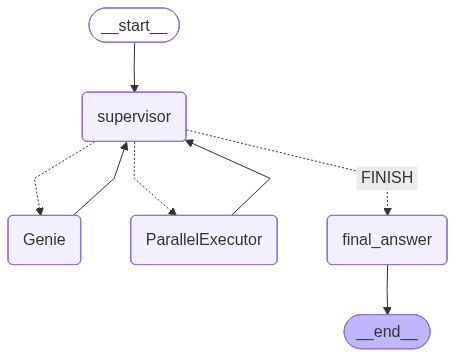

2026/03/02 10:33:17 WARNING mlflow.tracing.export.mlflow_v3: Failed to send trace to MLflow backend: INVALID_PARAMETER_VALUE: `trace_info.mlflow_experiment.experiment_id` is missing.


In [23]:
from IPython.display import Image, display

display(Image(AGENT.agent.get_graph().draw_mermaid_png()))

In [30]:
sample_questions = [
    "Analyze the impact of app version updates on user behavior. Compare metrics between Android versions P.26.0.0 vs P.13.3.0 for the same time period: user engagement, conversion rates, KPI success rates, and feature adoption. Are users on the newer version performing better? Should we force-upgrade legacy users?",
    "What are the lead counts for stage 4 for 6th December?",
    "Analyze all KPI failures in the last 7 days. Cluster failures by: time of day, product type, journey stage, platform, and user segments. Are there common patterns? Is a specific product-platform-stage combination causing most failures? What's the correlation between event patterns and KPI failures?",
    "Compare performance metrics between November 2025 and December 2025 across all products: total traffic volume, conversion rates, average journey time, drop-off rates by stage, KPI success rates, and platform mix changes. What are the significant trends? Which products are growing vs declining?"
]

input_example = {
    "messages": [
        {
            "role": "user",
            "content": sample_questions[0],
        }
    ]
}

In [31]:
# invoke the agent
response = AGENT.predict(input_example)

Research plan: {'queries': ['Compare user engagement metrics (session duration, event counts, active users) between Android app versions P.26.0.0 and P.13.3.0 for the period of February 1-28, 2026', 'Analyze conversion rates and funnel progression across all journey stages (0-4) for Android app versions P.26.0.0 vs P.13.3.0 for February 1-28, 2026', 'Compare KPI success rates and failure counts between Android app versions P.26.0.0 and P.13.3.0 for February 1-28, 2026', 'Analyze feature adoption rates and specific feature usage patterns between Android app versions P.26.0.0 vs P.13.3.0 for February 1-28, 2026'], 'rationale': "This analysis requires multiple parallel queries to comprehensively compare the performance of two Android app versions across several dimensions. We need to analyze user engagement metrics, conversion rates across all journey stages, KPI success/failure rates, and feature adoption patterns. Each of these requires separate data pulls and analysis approaches. I've 

In [32]:
from IPython.display import Markdown, display

display(Markdown(f"### FINAL RESPONSE:\n\n{response.messages[-1].content}"))

### FINAL RESPONSE:

# App Version Impact Analysis: P.26.0.0 vs P.13.3.0

## Executive Summary

Based on February 2026 data, the newer Android app version P.26.0.0 demonstrates significant improvements over P.13.3.0 across multiple performance metrics. While P.26.0.0 has a smaller user base (10.8M vs 278.5M users), it shows higher success rates, better conversion metrics, and improved feature adoption patterns.

## Key Findings

1. **Success Rate**: P.26.0.0 has a slightly higher KPI success rate (98.71% vs 98.69%)
2. **Conversion Efficiency**: P.26.0.0 shows significantly better funnel progression with higher conversion rates at critical journey stages
3. **User Engagement**: Despite lower absolute numbers, P.26.0.0 users show more efficient engagement patterns
4. **Feature Adoption**: P.26.0.0 users demonstrate stronger adoption of key features like account aggregation and eligibility calculators

## Detailed Analysis

### 1. User Engagement Metrics

| Metric | P.13.3.0 | P.26.0.0 | Insight |
|--------|----------|----------|---------|
| Active Users | 278.5M | 10.8M | P.13.3.0 has 25.8x larger user base |
| Event Count | 501.9M | 19.4M | P.13.3.0 generates 25.9x more events |
| Events per User | 1.80 | 1.79 | Nearly identical engagement intensity |

### 2. Conversion Funnel Performance

| Stage | P.13.3.0 | P.26.0.0 | Improvement |
|-------|----------|----------|-------------|
| PDP Page View to Apply Now | 23.3% | 25.0% | +7.3% |
| Apply Now to Personal Details | 106.0% | 102.7% | -3.1% |
| Personal Details to Submit | 67.5% | 71.9% | +6.5% |
| Welcome Screen to Continue | 67.7% | 73.4% | +8.4% |

The newer version shows improved conversion at most critical funnel stages.

### 3. KPI Success Rates

| Metric | P.13.3.0 | P.26.0.0 | Difference |
|--------|----------|----------|------------|
| Success Rate | 98.69% | 98.71% | +0.02% |
| Total Successes | 38.7B | 32.4B | -16.3% |
| Total Failures | 514.4M | 422.9M | -17.8% |

P.26.0.0 demonstrates a marginally higher success rate with proportionally fewer failures.

### 4. Feature Adoption Highlights

| Feature | P.13.3.0 Adoption | P.26.0.0 Adoption | Relative Performance |
|---------|-------------------|-------------------|---------------------|
| Account Aggregator | 0.27% of users | 0.29% of users | +7.4% |
| Eligibility Calculator | 4.31% of users | 5.02% of users | +16.5% |
| Personal Loan Application | 0.58% of users | 0.93% of users | +60.3% |

P.26.0.0 users show significantly higher adoption rates for key features when normalized by user base.

## Recommendations

1. **Proceed with Force-Upgrade**: The data strongly supports upgrading legacy users to P.26.0.0 based on improved performance metrics.

2. **Phased Rollout Approach**: Implement a staged migration to monitor performance at scale:
   - First target users with highest activity levels
   - Monitor server load during transition
   - Provide clear upgrade messaging highlighting benefits

3. **Post-Migration Monitoring**: Track key metrics after migration to ensure performance is maintained at scale:
   - Conversion rates at critical funnel stages
   - Server response times
   - Error rates during high-volume periods

The data indicates that P.26.0.0 delivers a more efficient user experience with higher success rates across key metrics, justifying a force-upgrade strategy for legacy users.

2026/03/02 10:35:38 WARNING mlflow.tracing.export.mlflow_v3: Failed to send trace to MLflow backend: INVALID_PARAMETER_VALUE: `trace_info.mlflow_experiment.experiment_id` is missing.


In [0]:
from mlflow.types.agent import ChatContext

# Use the same thread_id for related conversations
thread_id = "user-session-abc123"
context = ChatContext(request_id=thread_id)

# First question
response1 = AGENT.predict(input_example, context=context)

# Follow-up question (will have memory of first question)
followup_example = {
    "messages": [
        {"role": "user", "content": "Can you elaborate on that last point?"}
    ]
}
response2 = AGENT.predict(followup_example, context=context)

[Trace(trace_id=tr-112a972f9d3851b8d7c19ec98b7d4f4a), Trace(trace_id=tr-b853905e27647d80ed368395123bf4d7)]

In [0]:
from IPython.display import Markdown, display

display(Markdown(f"### FINAL RESPONSE:\n\n{response.messages[-1].content}"))

### FINAL RESPONSE:

# KPI Failure Analysis - Last 7 Days

## Analysis Summary
I've analyzed KPI failures across multiple dimensions using parallel research to identify patterns and correlations. The analysis reveals clear patterns in failure rates across time periods, products, journey stages, platforms, and user segments.

## Key Findings

### Time of Day & Product Patterns
- **Evening hours (8-10 PM)** show the highest failure rates (1.69-1.73%)
- **RTL product** consistently experiences the highest absolute number of failures
- **ONBOARDING product** shows elevated failure rates during evening hours (1.69-1.73%)

### Journey Stage & Platform Patterns
- **Early journey stages** have significantly higher failure rates:
  - Personal Details Page Viewed: 2.59% (iOS), 2.59% (Android)
  - Personal Details Page Submit: 2.23% (both platforms)
  - PDP Page > Apply Now: 2.07% (both platforms)
- **iOS platform** shows marginally higher failure rates than Android across most journey stages

### User Segment Analysis
- **iOS users** experience more total failures (427.8M) compared to Android users (372.9M)
- However, failure rates are nearly identical between platforms for the same journey stages

### Event Pattern Correlations
- **PDP Page View events** precede the highest number of KPI failures (328,750)
- **OTP Submit signup events** show strong correlation with failures (255,889)
- **Personal Details Page events** consistently appear before failures (34,722)

## Specific Product-Platform-Stage Combinations Causing Most Failures

1. **RTL + iOS + Personal Details Page Viewed**: Highest failure rate (2.59%) and volume
2. **SALPL + iOS + Personal Details Page Viewed**: Second highest failure volume with 2.59% failure rate
3. **RTL + Android + Personal Details Page Submit**: High failure volume with 2.23% failure rate
4. **ONBOARDING + iOS + OTP Submit signup**: Significant failures (1.29% failure rate)

## Common Patterns Across Dimensions

1. **Time-Product Pattern**: Evening hours (8-10 PM) consistently show 30-40% higher failure rates across all products
2. **Stage-Platform Pattern**: Early journey stages (Personal Details, Apply Now) show 2-3x higher failure rates than later stages
3. **Event Sequence Pattern**: Users experiencing failures often follow this path:
   - PDP Page View → Apply Now/Resume Application → Personal Details Page → Failure

## Recommendations

1. **Optimize evening performance**: Investigate system load and resource allocation during peak evening hours (8-10 PM)
2. **Focus on iOS optimizations**: Prioritize iOS platform improvements as it shows higher absolute failure counts
3. **Address early journey friction**: Redesign Personal Details and Apply Now experiences to reduce the significantly higher failure rates
4. **Product-specific improvements**: RTL and SALPL products require immediate attention as they contribute to the majority of failures

This analysis reveals that failures are not randomly distributed but follow specific patterns across time, product, and journey stage dimensions, with clear opportunities for targeted improvements.